[\[GitHub\] Jupyter Notebook](https://github.com/sslastochkin/mcab/blob/main/docs/guide/08_power_boosting.ipynb)
  
# Power Boosting Methods

Statistical power is the probability of detecting a real effect — it depends on sample size, effect magnitude, and **metric variance**.  
The key insight: if we can reduce the variance of our metric without biasing the treatment effect estimate, we can detect smaller effects with the same sample size (or run shorter experiments).

This guide covers the main variance reduction techniques available in `mcab`:

| Method | Key idea | Best when |
|---|---|---|
| **CUPED** | Adjust for a single pre-experiment numeric covariate | Strong linear correlation with covariate |
| **Post-Stratification** | Remove between-strata variance via OHE + OLS | Good categorical segmentation exists |
| **CUPAC** | Generalise both with any sklearn regressor | Multiple covariates available |
| **Custom transformer** | Plug any function into mcab's API | Non-standard methods (Ridge, boosting, etc.) |
| **Linearization** | Make ratio metrics IID-compatible first | CTR, average bill, and other ratios |

!!! info "Key property of all these methods"
    The treatment effect estimate remains **unbiased** — only variance changes.


## Setup & Data Generation

We generate synthetic ARPU-like data (exponential distribution) with:
- A numeric **covariate** — a noisy pre-experiment version of the metric (strong correlation → high variance reduction potential)
- Categorical **strata** — decile buckets derived from the same pre-experiment signal


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import OneHotEncoder

from mcab import (
    RandomData,
    AaDataIid,
    AaDataRatio,
    DesignerIid,
    DesignerRatioLin,
    CUPED,
    PostStratification,
    CUPAC,
    coef_pvalue_table,
    BenchMarker,
)

Generating sandbox data:

In [2]:
rdata = RandomData(seed=42)

def get_covariate(data: pd.Series) -> pd.Series:
    """Noisy pre-experiment version of the metric (simulates historical data)."""
    noise = np.random.default_rng(0).normal(0, data.std(), size=len(data))
    return pd.Series(data.values + noise, name='covariate')

def get_strats(data: pd.Series) -> pd.DataFrame:
    """Decile-based categorical strata from the metric."""
    tiny_noise = np.random.default_rng(1).normal(0, 1e-6, size=len(data))
    labels = [f"decile_{i}" for i in range(1, 11)]
    buckets = pd.qcut(data.values + tiny_noise, q=10, duplicates='drop', labels=labels)
    return pd.DataFrame({'strat': buckets.astype(str)})

# --- Generate ARPU data (exponential, high variance) ---
arpu_raw = pd.Series(rdata.exponential_data(size=10_000))
arpu_cov  = get_covariate(arpu_raw)        # single numeric covariate for CUPED
arpu_str  = get_strats(arpu_raw)           # categorical strata for PostStrat
arpu_X    = pd.concat([arpu_cov, arpu_str], axis=1)  # combined for CUPAC

# --- Base p-value function (Welch's t-test) ---
pval_func = lambda t, c: stats.ttest_ind(t, c, equal_var=False).pvalue

print(f"Dataset shape: {len(arpu_raw):,} users")
print(f"ARPU stats  : mean={arpu_raw.mean():.1f}, std={arpu_raw.std():.1f}")
print(f"Covariate correlation with target: r={arpu_raw.corr(arpu_cov):.3f}")


Dataset shape: 10,000 users
ARPU stats  : mean=988.7, std=992.5
Covariate correlation with target: r=0.704


## CUPED — Controlled-experiment Using Pre-Experiment Data

**Formula:** $y_{\text{adj}} = y - \hat{\theta} \cdot X_{\text{pre}}$

where $\hat{\theta} = \text{Cov}(y, X_{\text{pre}}) / \text{Var}(X_{\text{pre}})$ is the OLS slope.

**Variance reduction:**  
$\text{Var}(y_{\text{adj}}) = \text{Var}(y)(1 - \rho^2)$, so the higher the correlation $\rho$ between the metric and its pre-experiment covariate, the greater the reduction.

**Requirements:**
- A single **numeric** pre-experiment covariate
- The covariate must be **independent of the treatment** (collected before randomization)
- Works on IID data and on linearized ratio metrics

In `mcab`: [`CUPED`](https://sslastochkin.github.io/mcab/api/transform/#mcab.transform.CUPED) is a subclass of `CUPAC` with a fixed OLS model on one covariate.



CUPED results:
  Variance reduction : 49.6%
  θ (OLS slope)      : 0.5009
  Adjusted std       : 704.38  (raw std: 992.53)


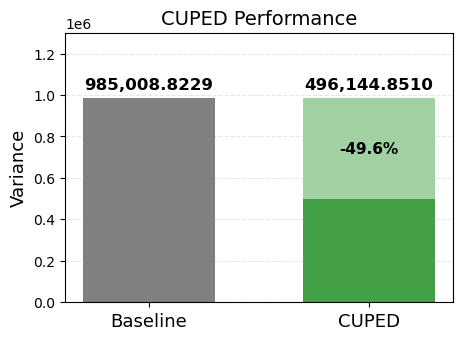

In [3]:
cuped = CUPED()

# Fit on the full dataset and compute adjusted metric
# cuped(X, y) = y - theta * X_pre
cuped_adj = cuped.cuped(X=arpu_cov, y=arpu_raw)   # returns adjusted array

# Variance-reduction diagnostics
cuped_stats = cuped.score(X=arpu_cov, y=arpu_raw, plot=True)

print(f"\nCUPED results:")
print(f"  Variance reduction : {cuped_stats['var_reduction']:.1%}")
print(f"  θ (OLS slope)      : {cuped_stats['theta']:.4f}")
print(f"  Adjusted std       : {cuped_stats['resid_std']:.2f}  (raw std: {arpu_raw.std():.2f})")

## Post-Stratification

**Idea:** split users into strata (e.g. deciles by pre-experiment activity) and remove the between-strata mean differences from the metric.

**Mechanism:** OLS regression of $y$ on stratum indicator dummies → the residuals $y - \hat{y}_{\text{stratum}}$ have lower variance because strata explain a portion of it.

Compared to CUPED:
- Works with **categorical** covariates (no need for a numeric pre-experiment variable)
- The more homogeneous users are within strata (and the more different across strata), the better
- In `mcab`: [`PostStratification`](https://sslastochkin.github.io/mcab/api/transform/#mcab.transform.PostStratification) handles OHE automatically — you can pass raw `pd.qcut` output



Post-Stratification results:
  Variance reduction : 89.5%
  Adjusted std       : 320.90  (raw std: 992.53)

Coefficient table (OLS on stratum dummies):


,feature,coef,se,stat,pvalue
0,(Intercept),3284.851719,30.971049,106.062011,0.0
1,strat_decile_1,-3234.624728,30.985454,-104.391717,0.0
2,strat_decile_2,-3125.391159,30.989854,-100.852077,0.0
3,strat_decile_3,-2996.935929,30.995119,-96.690576,0.0
4,strat_decile_4,-2855.359617,30.999774,-92.109047,0.0
5,strat_decile_5,-2692.106416,31.015852,-86.797757,0.0
6,strat_decile_6,-2497.844107,31.029480,-80.499063,0.0
7,strat_decile_7,-2258.234938,31.069320,-72.683758,0.0
8,strat_decile_8,-1918.120308,31.196683,-61.484752,0.0
9,strat_decile_9,-1382.896033,31.622174,-43.731846,0.0


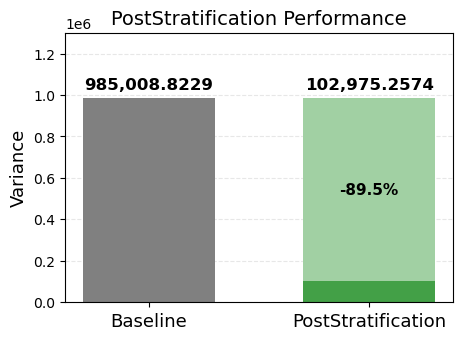

In [4]:
pstrat = PostStratification()

# Fit and score: strats are categorical → auto-encoded via OneHotEncoder
pstrat_adj   = arpu_raw - pstrat.fit_predict(X=arpu_str, y=arpu_raw)
pstrat_stats = pstrat.score(X=arpu_str, y=arpu_raw, plot=True)

print(f"\nPost-Stratification results:")
print(f"  Variance reduction : {pstrat_stats['var_reduction']:.1%}")
print(f"  Adjusted std       : {pstrat_stats['resid_std']:.2f}  (raw std: {arpu_raw.std():.2f})")

# Inspect which strata contribute most (coefficient significance)
print("\nCoefficient table (OLS on stratum dummies):")
coef_pvalue_table(pstrat, arpu_str, arpu_raw)

## CUPAC — Combining CUPED and Post-Stratification

**CUPAC** (Control Using Predictions As Covariates) is the generalisation: fit any ML-model on pre-experiment features $X$, use the predictions as the covariate adjustment.

$$y_{\text{adj}} = y - \hat{f}(X)$$

When $\hat{f}$ is OLS on a single numeric column → **CUPED**.  
When $\hat{f}$ is OLS on one-hot encoded strata → **Post-Stratification**.  
When $\hat{f}$ uses both together → **CUPAC** (typically the strongest).

!!! tip "Why combine?"  
    The residual variance after joint adjustment is always ≤ either method alone, as long as the model doesn't overfit (which OLS avoids at reasonable feature counts).



CUPAC (OLS) results:
  Variance reduction : 90.5%
  Adjusted std       : 306.28  (raw std: 992.53)


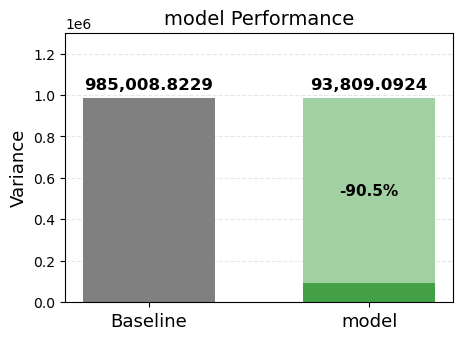

In [5]:
# CUPAC with OLS on covariate + strata (= CUPED + PostStrat in one model)
cupac_ols = CUPAC(LinearRegression(fit_intercept=True, copy_X=False))

cupac_ols.fit(
    X=arpu_X,
    y=arpu_raw,
    cat_cols=['strat'],
    cat_encoder=lambda categories: OneHotEncoder(
        categories=categories, drop='first', sparse_output=False, handle_unknown='ignore'
    )
)

cupac_adj   = arpu_raw - cupac_ols.predict(arpu_X)
cupac_stats = cupac_ols.score(arpu_X, arpu_raw, plot=True)

print(f"\nCUPAC (OLS) results:")
print(f"  Variance reduction : {cupac_stats['var_reduction']:.1%}")
print(f"  Adjusted std       : {cupac_stats['resid_std']:.2f}  (raw std: {arpu_raw.std():.2f})")


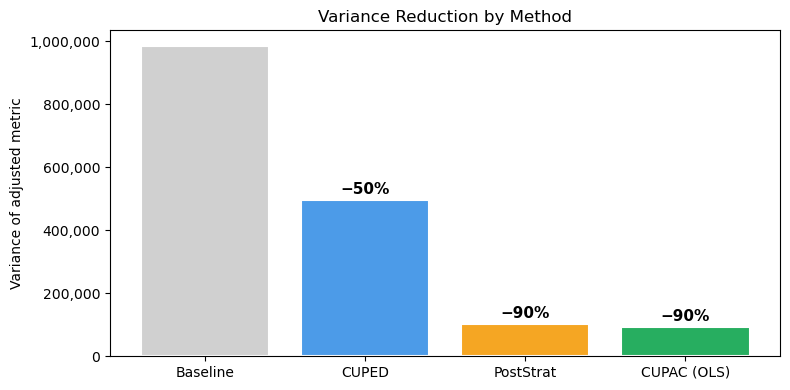

,method,variance,var_reduction
0,Baseline,985107.3337,0.0000
1,CUPED,496194.4704,0.4963
2,PostStrat,102985.5560,0.8955
3,CUPAC (OLS),93818.4743,0.9048


In [6]:
# --- Side-by-side variance comparison ---
methods = ['Baseline', 'CUPED', 'PostStrat', 'CUPAC (OLS)']
variances = [
    arpu_raw.var(),
    cuped_adj.var(),
    pstrat_adj.var(),
    cupac_adj.var(),
]
reductions = [0] + [1 - v / arpu_raw.var() for v in variances[1:]]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#d0d0d0', '#4c9be8', '#f5a623', '#27ae60']
bars = ax.bar(methods, variances, color=colors, edgecolor='white', linewidth=1.5)

for bar, red in zip(bars[1:], reductions[1:]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + arpu_raw.var() * 0.01,
        f'−{red:.0%}', ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax.set_ylabel('Variance of adjusted metric')
ax.set_title('Variance Reduction by Method')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

pd.DataFrame({'method': methods, 'variance': variances, 'var_reduction': reductions}).round(4)


In [7]:
print("CUPAC coefficient table — which features matter most?")
coef_pvalue_table(cupac_ols, arpu_X, arpu_raw)

CUPAC coefficient table — which features matter most?


,feature,coef,se,stat,pvalue
0,(Intercept),2980.948202,24.639739,120.981321,0.000000e+00
1,strat_decile_1,-2938.292718,24.563621,-119.619688,0.000000e+00
2,strat_decile_2,-2835.720873,24.403425,-116.201760,0.000000e+00
3,strat_decile_3,-2721.202903,23.991815,-113.422137,0.000000e+00
4,strat_decile_4,-2594.708935,23.667140,-109.633395,0.000000e+00
5,strat_decile_5,-2441.345923,23.465682,-104.038991,0.000000e+00
6,strat_decile_6,-2267.594445,23.217657,-97.666807,0.000000e+00
7,strat_decile_7,-2049.655444,23.049248,-88.925046,0.000000e+00
8,strat_decile_8,-1739.001864,23.230258,-74.859342,0.000000e+00
9,strat_decile_9,-1252.986392,24.305108,-51.552389,0.000000e+00


## Flexible API: Plugging Any Transformer into mcab

The power of mcab's design is that **any variance reduction method** can be integrated through a single interface:

```python
transformer = lambda X, y: adjusted_y   # returns adjusted metric
data = AaDataIid(raw_data, transformer=transformer, covariates=X)
```
  
The `transformer` function is called inside each Monte Carlo simulation iteration:
  
1. Effect is injected into the test group
2. Linearization is applied (if ratio metric)
3. Your `transformer` is called → returns adjusted metric
4. `pval_func` is applied to get the p-value
  
This means you can use Ridge regression, Gradient Boosting, propensity score weighting — anything that takes `(X, y)` and returns an adjusted `y`.  
  
### Example: Ridge regression as the adjustment model
  
Ridge adds L2 regularization: 

For high-dimensional feature sets or multicollinear covariates, Ridge can outperform plain OLS.

CUPAC (OLS)   variance reduction: 90.5%
CUPAC (Ridge) variance reduction: 90.5%


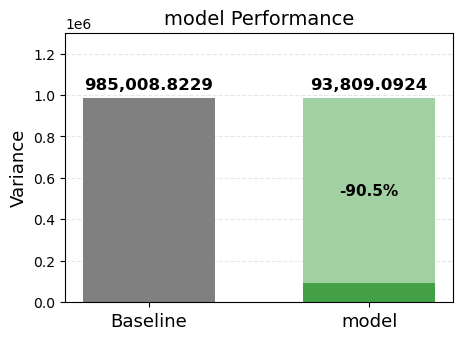

In [8]:
# -----------------------------------------------------------------------
# Named helper functions — required for correct joblib serialization
# when n_jobs=-1. Nested lambdas are NOT picklable correctly by joblib.
# -----------------------------------------------------------------------

from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge
from mcab import CUPED, PostStratification, CUPAC

def _ohe_factory(categories):
    """OHE factory: named function so joblib can pickle it across workers."""
    return OneHotEncoder(
        categories=categories,
        drop='first',
        sparse_output=False,
        handle_unknown='ignore',
    )

def cuped_transform(X, y):
    return y - CUPED().fit_predict(X, y)

def pstrat_transform(X, y):
    return y - PostStratification().fit_predict(X, y)

def cupac_ols_transform(X, y):
    return y - CUPAC(LinearRegression(fit_intercept=True, copy_X=False)).fit_predict(
        X, y,
        cat_cols=['strat'],
        cat_encoder=_ohe_factory,   # ← named function, not a nested lambda
    )

def cupac_ridge_transform(X, y):
    return y - CUPAC(Ridge(alpha=1.0, fit_intercept=True)).fit_predict(
        X, y,
        cat_cols=['strat'],
        cat_encoder=_ohe_factory,   # ← named function, not a nested lambda
    )

# Quick sanity check (single-process, no serialization needed here)
cupac_ols = CUPAC(LinearRegression(fit_intercept=True, copy_X=False))
cupac_ols.fit(arpu_X, arpu_raw, cat_cols=['strat'], cat_encoder=_ohe_factory)
cupac_stats = cupac_ols.score(arpu_X, arpu_raw, plot=True)

cupac_ridge = CUPAC(Ridge(alpha=1.0, fit_intercept=True))
cupac_ridge.fit(arpu_X, arpu_raw, cat_cols=['strat'], cat_encoder=_ohe_factory)
ridge_stats = cupac_ridge.score(arpu_X, arpu_raw, plot=False)

print(f"CUPAC (OLS)   variance reduction: {cupac_stats['var_reduction']:.1%}")
print(f"CUPAC (Ridge) variance reduction: {ridge_stats['var_reduction']:.1%}")

In [9]:
# --- Attach transformers to AaDataIid ---
# covariates= tells mcab which X to pass to the transformer inside each simulation

arpu_data_base   = AaDataIid(arpu_raw)
arpu_data_cuped  = AaDataIid(arpu_raw, transformer=cuped_transform,       covariates=arpu_cov)
arpu_data_pstrat = AaDataIid(arpu_raw, transformer=pstrat_transform,      covariates=arpu_str)
arpu_data_cupac  = AaDataIid(arpu_raw, transformer=cupac_ols_transform,   covariates=arpu_X)
arpu_data_ridge  = AaDataIid(arpu_raw, transformer=cupac_ridge_transform, covariates=arpu_X)

# --- Create designers (one per method) ---
des_base   = DesignerIid(arpu_data_base,   name='baseline',      pval_func=pval_func)
des_cuped  = DesignerIid(arpu_data_cuped,  name='CUPED',         pval_func=pval_func)
des_pstrat = DesignerIid(arpu_data_pstrat, name='PostStrat',     pval_func=pval_func)
des_cupac  = DesignerIid(arpu_data_cupac,  name='CUPAC (OLS)',   pval_func=pval_func)
des_ridge  = DesignerIid(arpu_data_ridge,  name='CUPAC (Ridge)', pval_func=pval_func)

print("Designers created:", [d.name for d in [des_base, des_cuped, des_pstrat, des_cupac, des_ridge]])

Designers created: ['baseline', 'CUPED', 'PostStrat', 'CUPAC (OLS)', 'CUPAC (Ridge)']


## Validation: Type I Error Control

Before trusting any variance reduction method, we must verify it **preserves Type I error** (false positive rate).

Variance reduction techniques adjust the metric using covariates estimated *within* each simulated split. If the adjustment introduces bias or inflates the test statistic distribution, the α-level is violated — we'd reject the null hypothesis more often than we should under H₀.

We validate using **AA simulations** (`aa_sims`): repeatedly split users into two equal groups (no treatment), apply the full pipeline (transform → t-test), and check that p-values are uniform on [0, 1].

!!! warning "⚠️ When can Type I error inflate?"
    If the transformer overfits to the current split — e.g., when using a high-capacity model (GBM, deep NN) on the same data used to fit the transformer. OLS/Ridge on a small number of features is generally safe.


Running AA simulations for all methods...
(This may take ~1-2 minutes with n_jobs=-1)



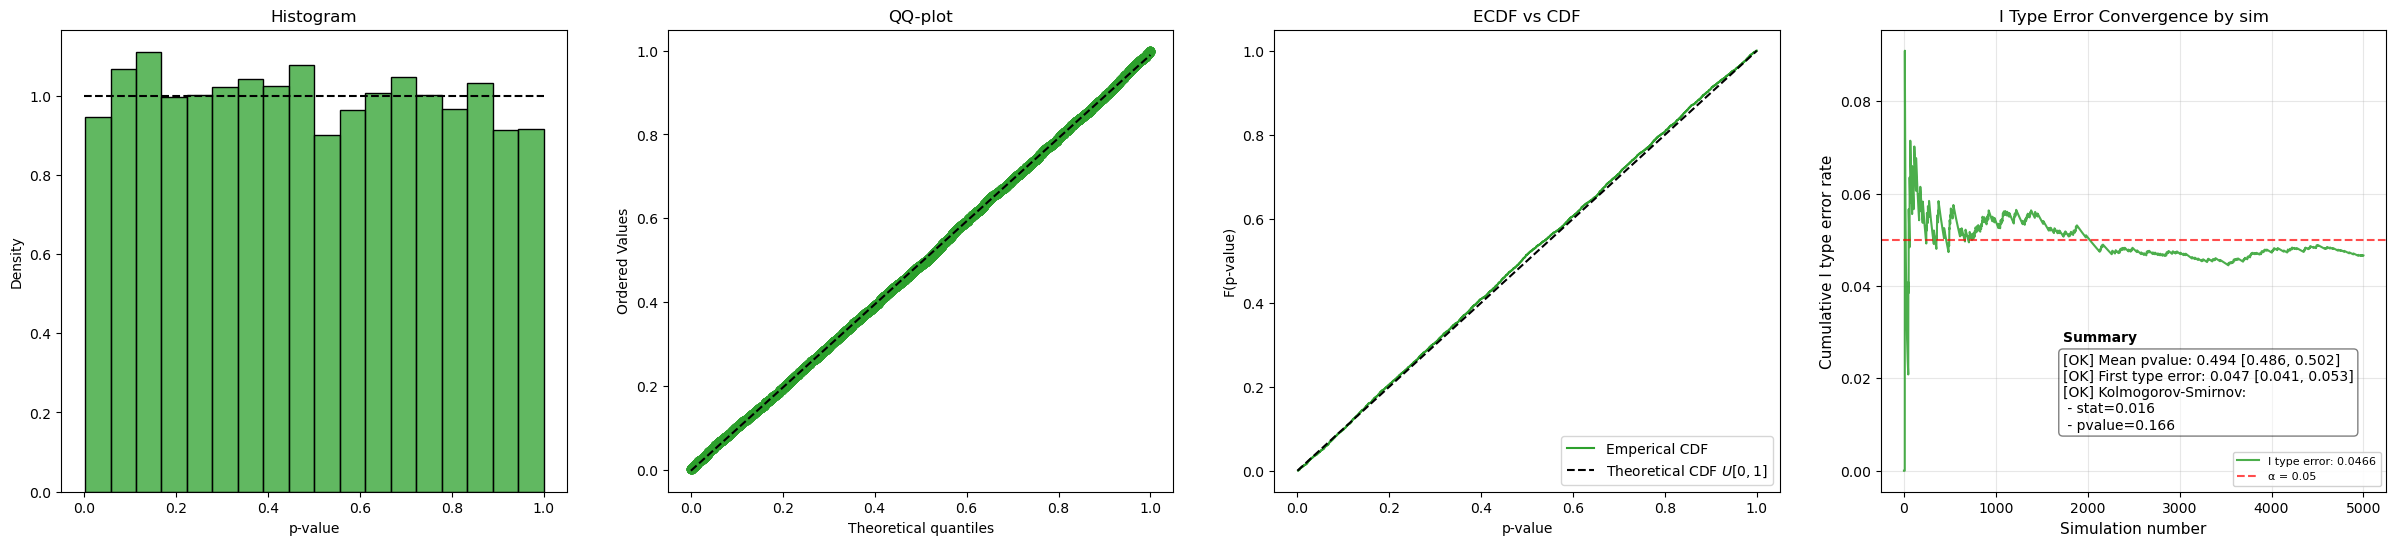

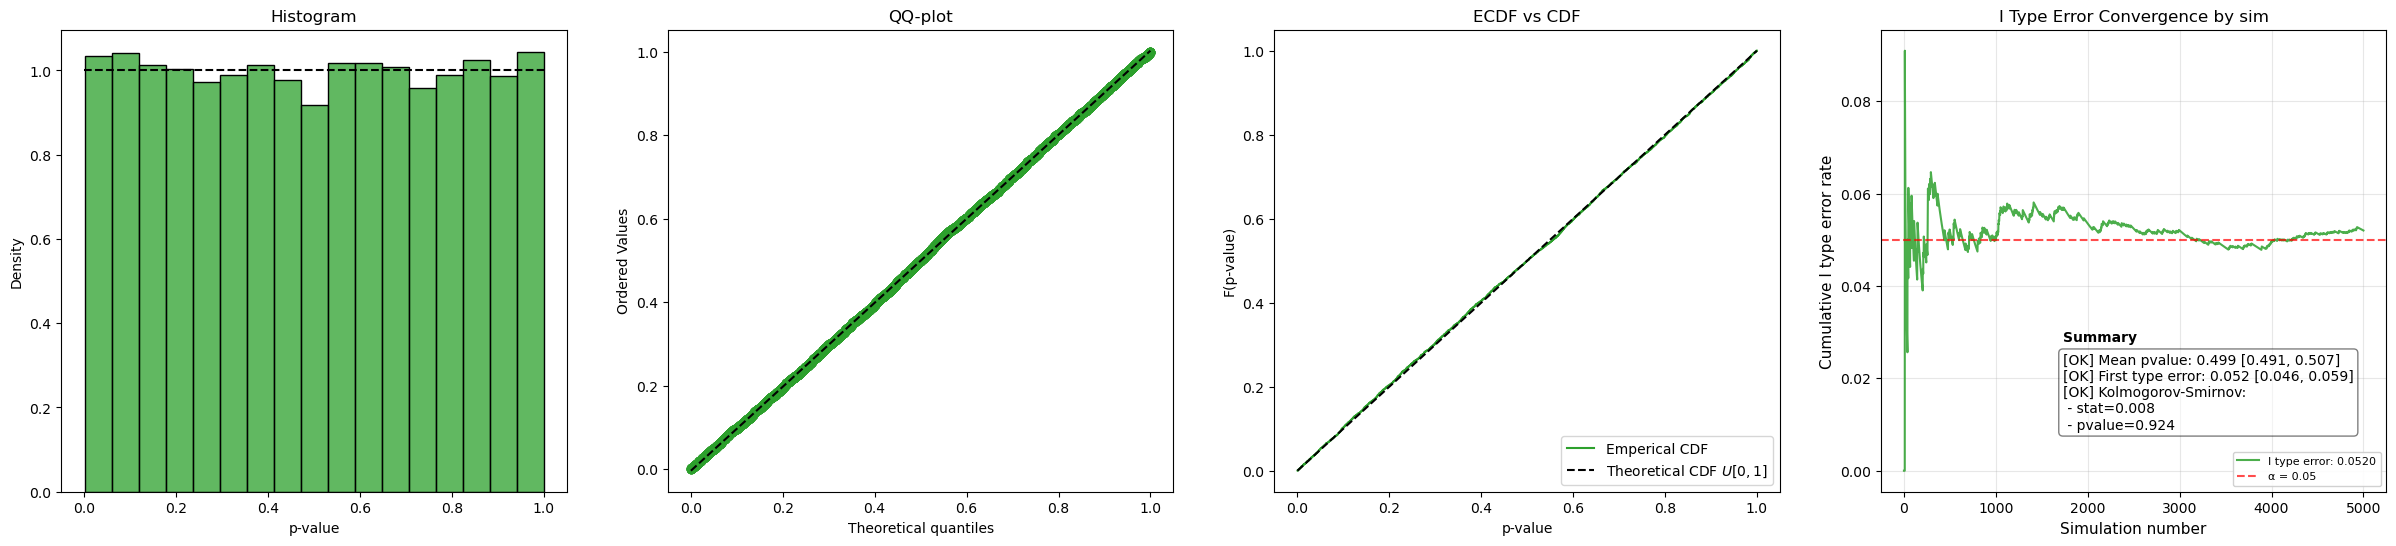

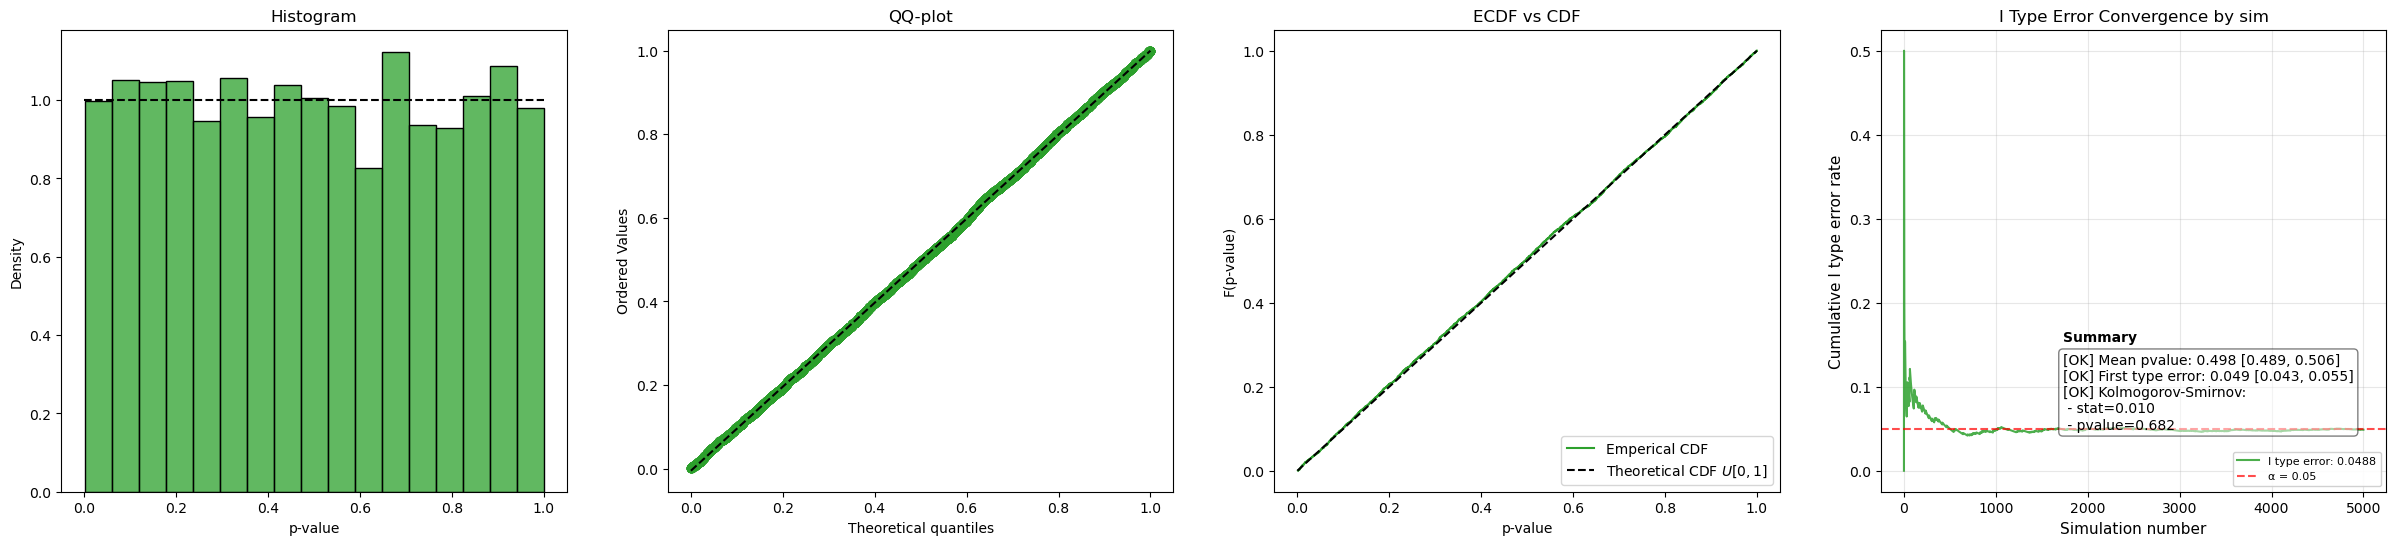

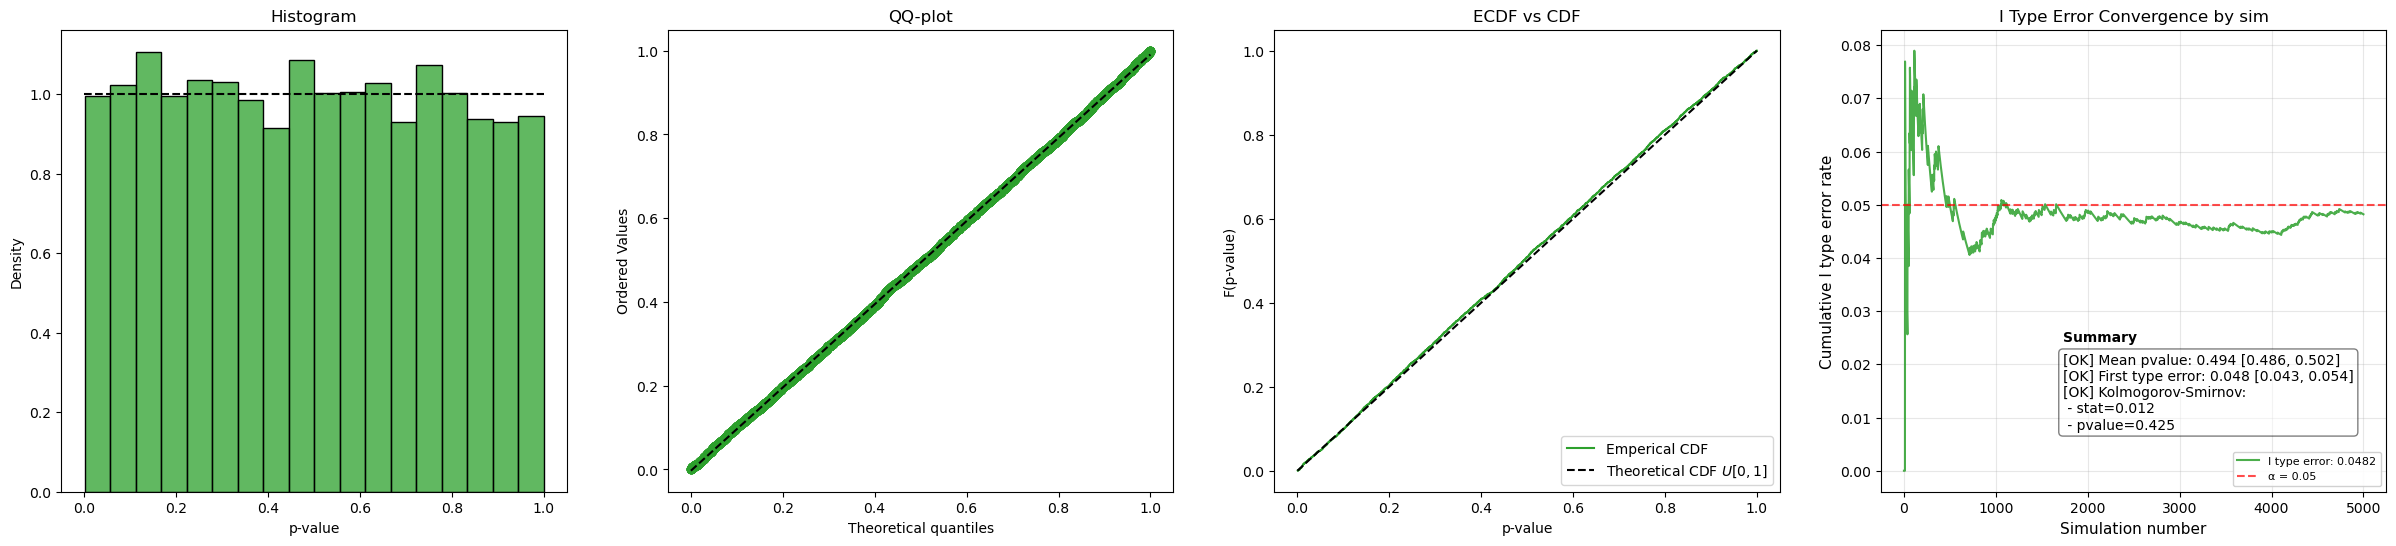

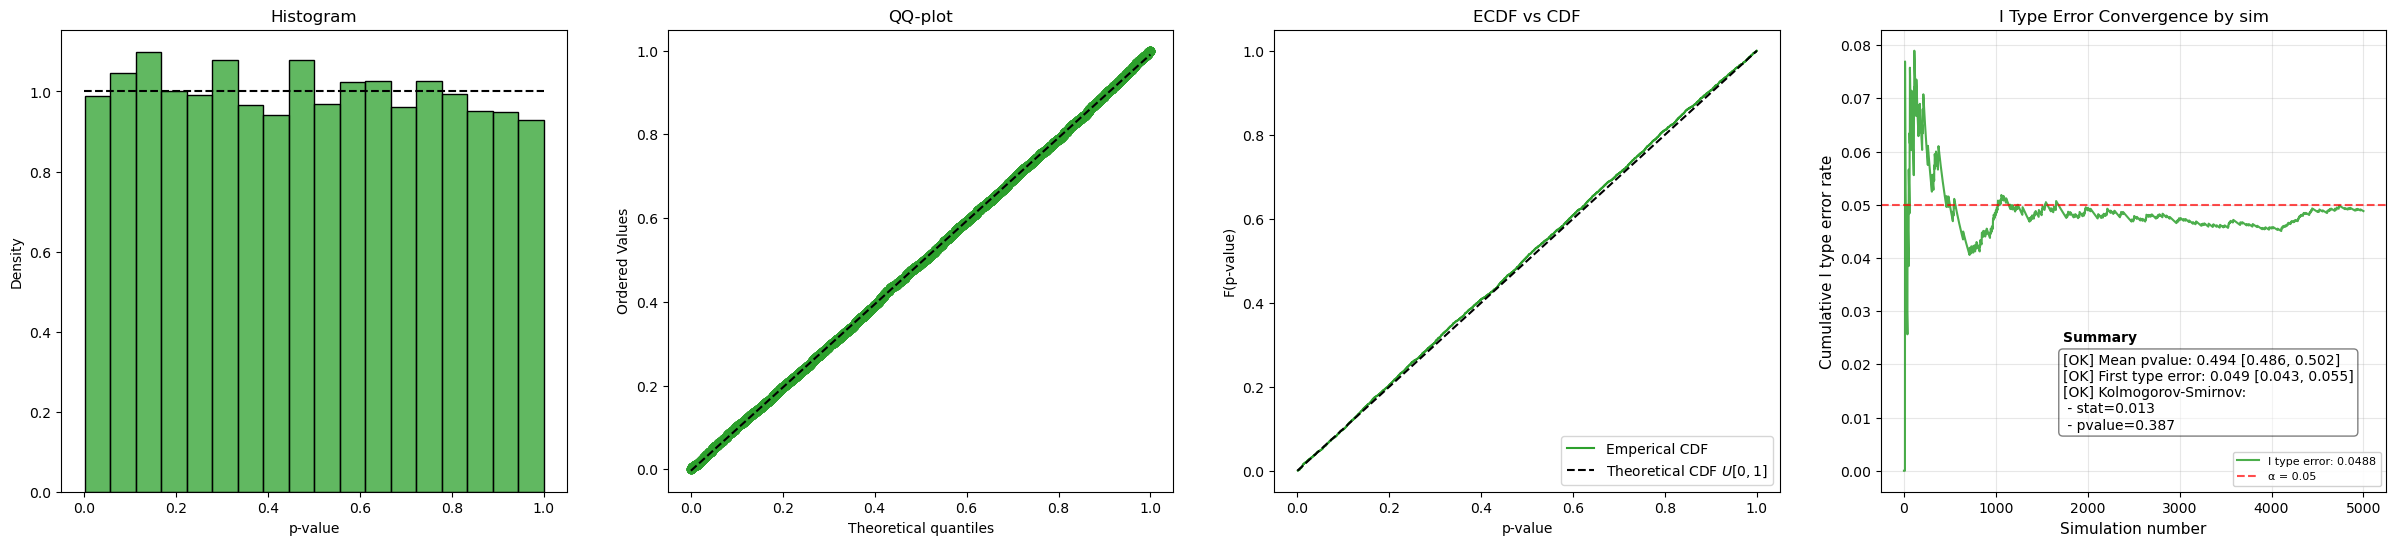

In [10]:
N_SIMS = 5_000

print("Running AA simulations for all methods...")
print("(This may take ~1-2 minutes with n_jobs=-1)\n")

aa_base   = des_base.aa_sims(  n_sims=N_SIMS, n_jobs=-1, verbose=False)
aa_cuped  = des_cuped.aa_sims( n_sims=N_SIMS, n_jobs=-1, verbose=False)
aa_pstrat = des_pstrat.aa_sims(n_sims=N_SIMS, n_jobs=-1, verbose=False)
aa_cupac  = des_cupac.aa_sims( n_sims=N_SIMS, n_jobs=-1, verbose=False)
aa_ridge  = des_ridge.aa_sims( n_sims=N_SIMS, n_jobs=-1, verbose=False)

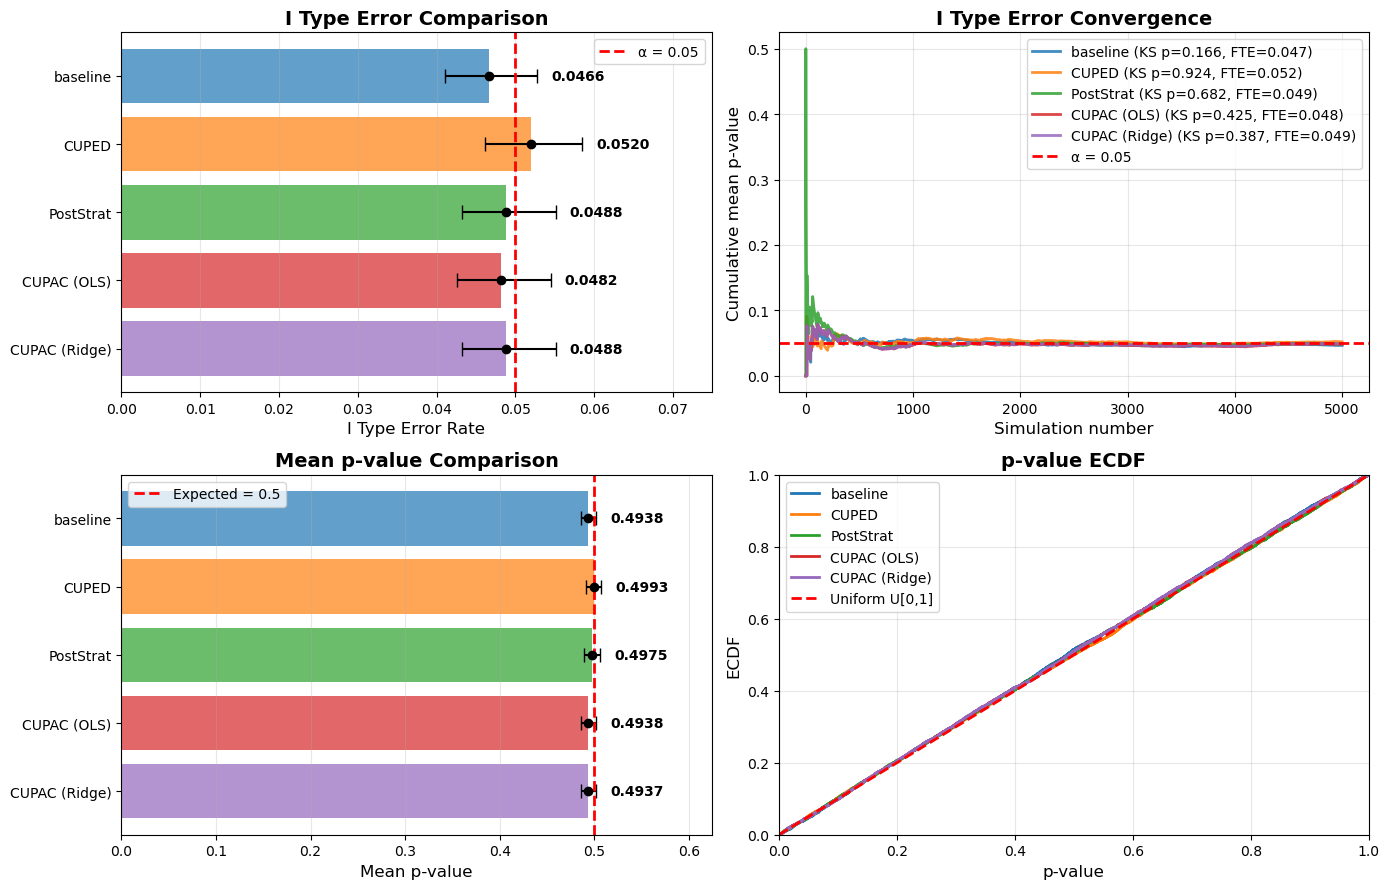


AA test summary (Type I error @ α=0.05):
[0.0466, 0.052, 0.0488, 0.0482, 0.0488]


In [11]:
designers_all = [des_base, des_cuped, des_pstrat, des_cupac, des_ridge]
bm = BenchMarker(designers_all)

# Runs AA benchmark and shows p-value distribution plots + summary table
aa_pvalues, aa_stats_table = bm.aa_benchmark(n_sims=N_SIMS, n_jobs=-1, verbose=False)

print("\nAA test summary (Type I error @ α=0.05):")
print([x['mean_p_ft'] for x in aa_stats_table])


## Power Comparison: Which Method Detects Effects Best?

After confirming Type I error is controlled, we compare **statistical power** — the probability of detecting a real effect of a given size.

We use [`BenchMarker.ab_benchmark`](https://sslastochkin.github.io/mcab/api/core/) which:
1. Injects a synthetic effect into the test group
2. Runs Monte Carlo A/B simulations for each designer
3. Reports power at the chosen effect size + power curves across a range of effects

### Variance reduction → lower MDE

The theoretical relationship is:
$$n_{\text{required}} \propto \frac{\sigma^2}{\Delta^2}$$

If a method reduces variance by 50%, the same sample size gives the same power at an effect ~30% smaller.


Variance comparison across methods:


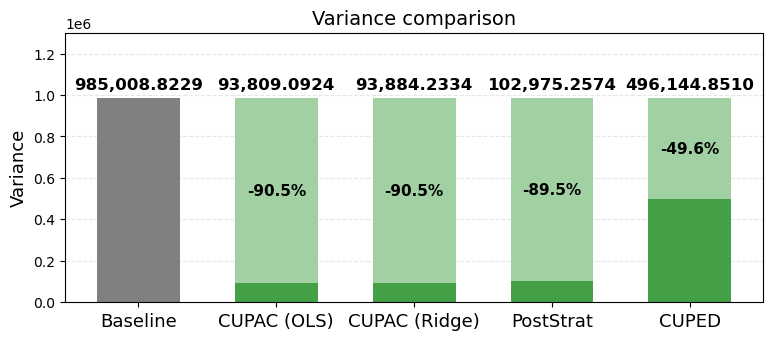

In [12]:
# First: compare variance reduction achieved by each method
# (useful to see which method wins before running full power simulations)
print("Variance comparison across methods:")
var_comparison = bm.compare_variance()


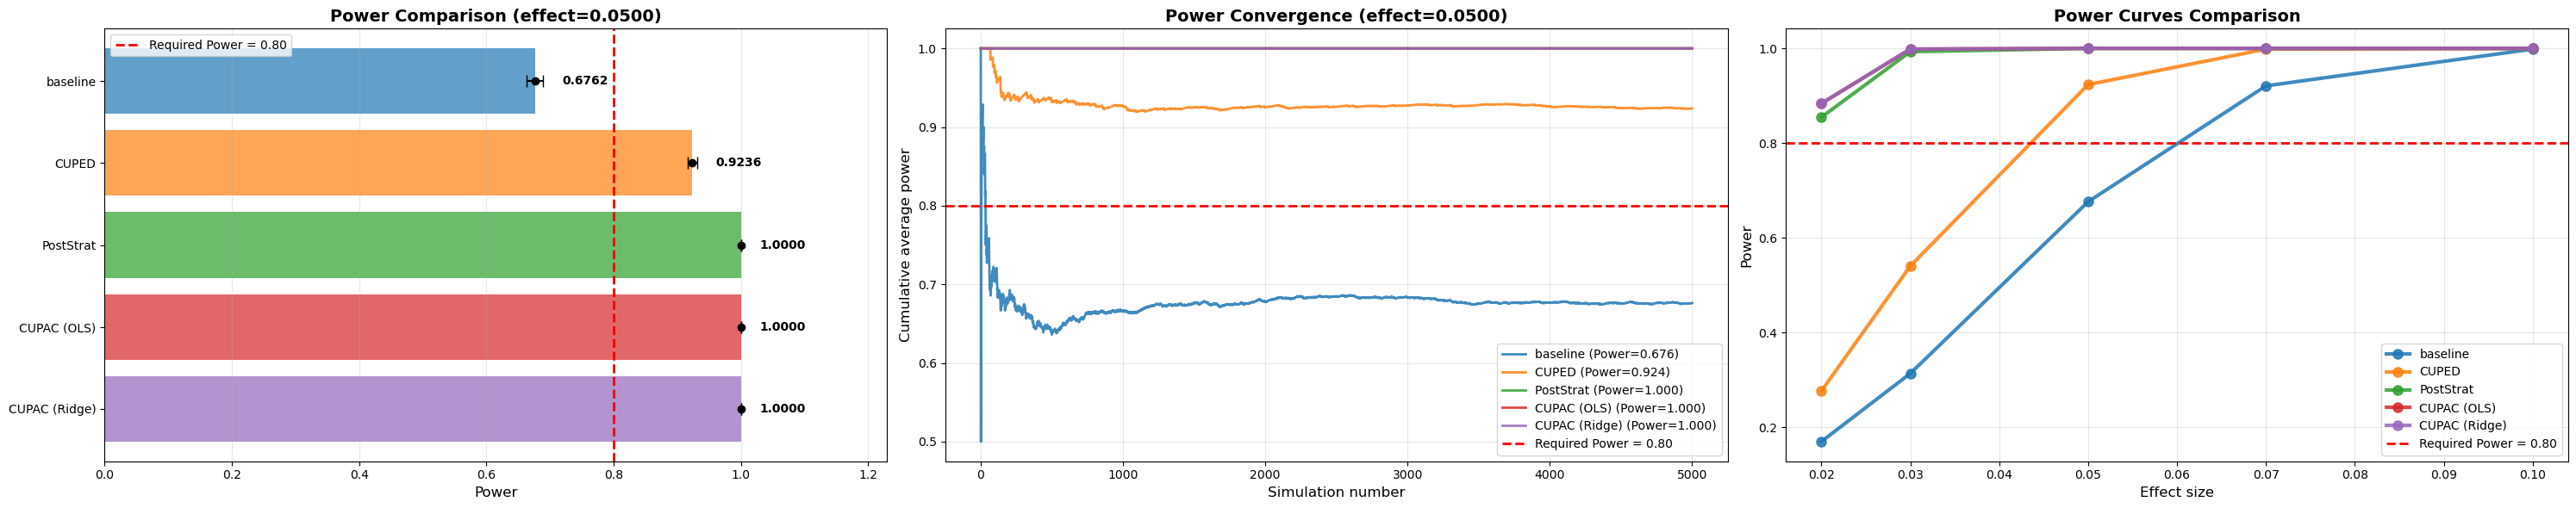


Power at 5% relative effect:
[0.6762, 0.9236, 1.0, 1.0, 1.0]


In [13]:
# AB benchmark: power at bar_effect + power curves across multiple effects
# bar_effect=0.05 means a 5% relative lift on the mean
ab_stats, power_curves = bm.ab_benchmark(
    bar_effect=0.05,
    power_curve_effects=[0.02, 0.03, 0.05, 0.07, 0.10],
    n_sims=N_SIMS,
    n_jobs=-1,
    verbose=False,
)

print("\nPower at 5% relative effect:")
print([x['mean_p'] for x in ab_stats])


Directional agreement: Baseline vs CUPAC (OLS)


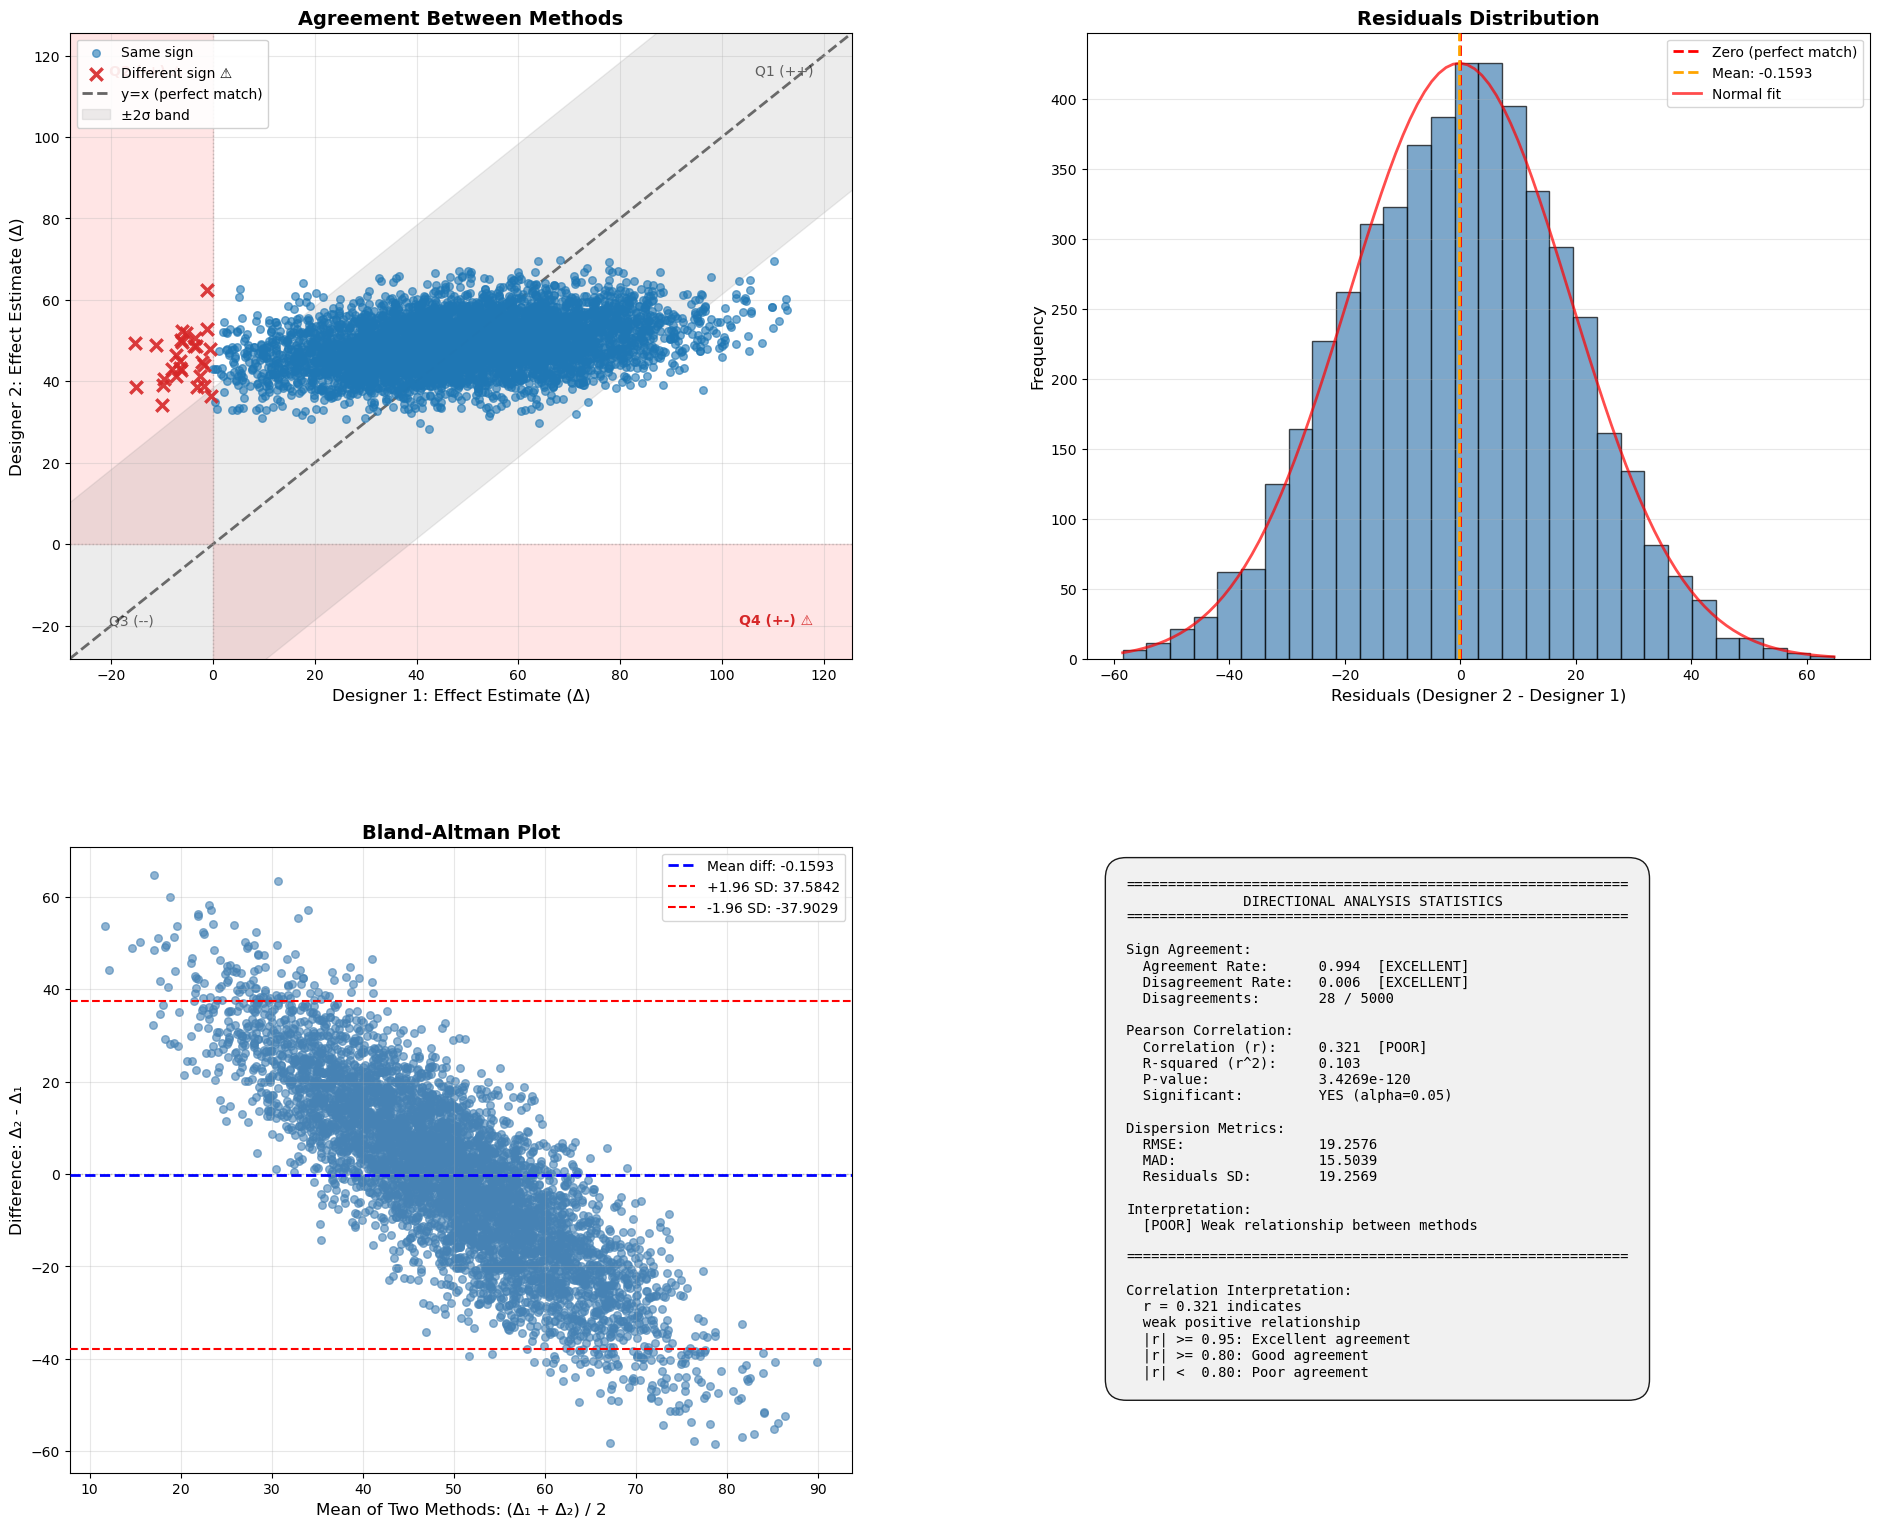

In [14]:
# Sign agreement analysis: how often do the adjusted metric and the raw metric
# point in the same direction? Disagreement means we can't trust the direction.
print("Directional agreement: Baseline vs CUPAC (OLS)")
directional = bm.directional_analysis(
    designer1=des_base,
    designer2=des_cupac,
    effect=0.05,
    n_sims=N_SIMS,
    n_jobs=-1,
    verbose=False,
)


### ⚠️ Sign Disagreement: What It Actually Means

When a variance-reduced metric and the raw metric **point in opposite directions**, neither result can be trusted — not the adjusted one, and not the raw one.

This is the critical nuance: sign disagreement does **not** mean "the raw metric is correct." It means the experiment has insufficient power to produce a stable signal in this run. Both estimates are noisy.

**Why does disagreement happen?**  
Variance reduction changes the metric's distribution. In rare cases (roughly ~α probability), random splits produce opposite noise in the raw vs. adjusted metric. This is a noise artefact, not a real signal — so using either direction would be misleading.

**Correct protocol:**
1. At analysis time, check `sign(adjusted_diff) == sign(raw_diff)`
2. If they **agree** → report the adjusted metric result (lower p-value, tighter CI, more power)
3. If they **disagree** → **do not conclude from either metric.** Extend the experiment and re-analyse when more data is available, or use a pre-specified alternative test method

**What NOT to do:**
- ❌ Do not report the raw metric as the "fallback truth" — it is equally unreliable in a disagreement scenario
- ❌ Do not cherry-pick the metric that shows significance

The mcab `directional_analysis` method quantifies how often disagreement occurs at a given effect size, helping you decide whether the method is safe for your experiment context.


## Ratio Metrics: Linearization First, Then Variance Reduction

Ratio metrics (CTR = clicks/sessions, average bill = revenue/orders) are **not IID** at the user level — users contribute different numbers of events, so the standard delta method is needed for correct inference.

**Linearization** converts a ratio metric into an IID-compatible metric:

$$y_i^{\text{lin}} = \text{num}_i - \hat{\theta} \cdot \text{denom}_i$$

where $\hat{\theta} = \sum \text{num}_c / \sum \text{denom}_c$ is the ratio estimated on the control group.

This linearized metric has the same expected value (treatment effect) as the ratio, but is now a simple sum — so t-tests, CUPED, PostStrat, and CUPAC all apply correctly.

**mcab workflow:**
1. Pass `(num_array, denom_array)` as a tuple to `AaDataRatio`
2. Optionally attach a `transformer` (variance reduction on the linearized metric)
3. Use `DesignerRatioLin` — it handles linearization internally before calling the transformer

> `Linearizer` in `mcab.transform` is also available for manual use when you want to inspect the linearized arrays directly.


In [15]:
# Generate avg_bill ratio data: (revenue_per_user, orders_per_user)
avg_bill_raw = rdata.ratio_data_avg_bill(size=10_000)  # returns (num, denom) tuple
num_arr, denom_arr = avg_bill_raw

# Manual linearization demo (for understanding)
from mcab import Linearizer

# Split 50/50 to show the concept
n = len(num_arr) // 2
test_tup    = (num_arr[:n], denom_arr[:n])
control_tup = (num_arr[n:], denom_arr[n:])

lin_test, lin_control, theta = Linearizer(
    test=test_tup,
    control=control_tup,
    use_pool_theta=False   # theta estimated from control only (recommended)
)

print(f"θ (control ratio)      : {theta:.4f}")
print(f"Control avg_bill       : {(num_arr[n:] / denom_arr[n:]).mean():.4f}")
print(f"Test avg_bill          : {(num_arr[:n] / denom_arr[:n]).mean():.4f}")
print(f"\nLinearized test  — mean: {lin_test.mean():.4f}, std: {lin_test.std():.4f}")
print(f"Linearized ctrl  — mean: {lin_control.mean():.4f}, std: {lin_control.std():.4f}")
print("\n→ Under H₀ (AA), both linearized means should be ~0 (centred around 0 by construction).")


θ (control ratio)      : 495.0149
Control avg_bill       : 640.3284
Test avg_bill          : 662.5330

Linearized test  — mean: 39.3681, std: 1682.2575
Linearized ctrl  — mean: -0.0000, std: 1658.1463

→ Under H₀ (AA), both linearized means should be ~0 (centred around 0 by construction).


In [16]:
# Covariates from the ratio metric (pre-experiment: use num/denom as proxy)
avg_ratio_series = pd.Series(num_arr / denom_arr)
avg_bill_cov     = get_covariate(avg_ratio_series)
avg_bill_str     = get_strats(avg_ratio_series)
avg_bill_X       = pd.concat([avg_bill_cov, avg_bill_str], axis=1)

# --- AaDataRatio: mcab handles linearization internally ---
# transformer is applied to the *linearized* metric, not the raw ratio
avg_bill_data        = AaDataRatio(avg_bill_raw)
avg_bill_data_cuped  = AaDataRatio(avg_bill_raw, transformer=cuped_transform,       covariates=avg_bill_cov)
avg_bill_data_pstrat = AaDataRatio(avg_bill_raw, transformer=pstrat_transform,      covariates=avg_bill_str)
avg_bill_data_cupac  = AaDataRatio(avg_bill_raw, transformer=cupac_ols_transform,   covariates=avg_bill_X)
avg_bill_data_ridge  = AaDataRatio(avg_bill_raw, transformer=cupac_ridge_transform, covariates=avg_bill_X)

# --- DesignerRatioLin: linearizes ratio, then applies transformer, then pval_func ---
des_ab_base   = DesignerRatioLin(avg_bill_data,        ratio='float', name='avg_bill',        pval_func=pval_func)
des_ab_cuped  = DesignerRatioLin(avg_bill_data_cuped,  ratio='float', name='avg_bill_cuped',  pval_func=pval_func)
des_ab_pstrat = DesignerRatioLin(avg_bill_data_pstrat, ratio='float', name='avg_bill_pstrat', pval_func=pval_func)
des_ab_cupac  = DesignerRatioLin(avg_bill_data_cupac,  ratio='float', name='avg_bill_cupac',  pval_func=pval_func)
des_ab_ridge  = DesignerRatioLin(avg_bill_data_ridge,  ratio='float', name='avg_bill_ridge',  pval_func=pval_func)

designers_ab = [des_ab_base, des_ab_cuped, des_ab_pstrat, des_ab_cupac, des_ab_ridge]
bm_ab = BenchMarker(designers_ab)

print("Designers for avg_bill ratio metric:")
print([d.name for d in designers_ab])


Designers for avg_bill ratio metric:
['avg_bill', 'avg_bill_cuped', 'avg_bill_pstrat', 'avg_bill_cupac', 'avg_bill_ridge']


=== Variance comparison on linearized avg_bill ===


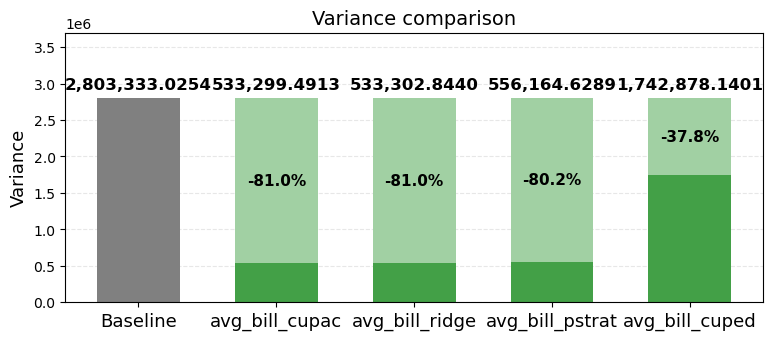

In [17]:
print("=== Variance comparison on linearized avg_bill ===")
var_cmp_ab = bm_ab.compare_variance()


=== Type I error check (AA benchmark) ===


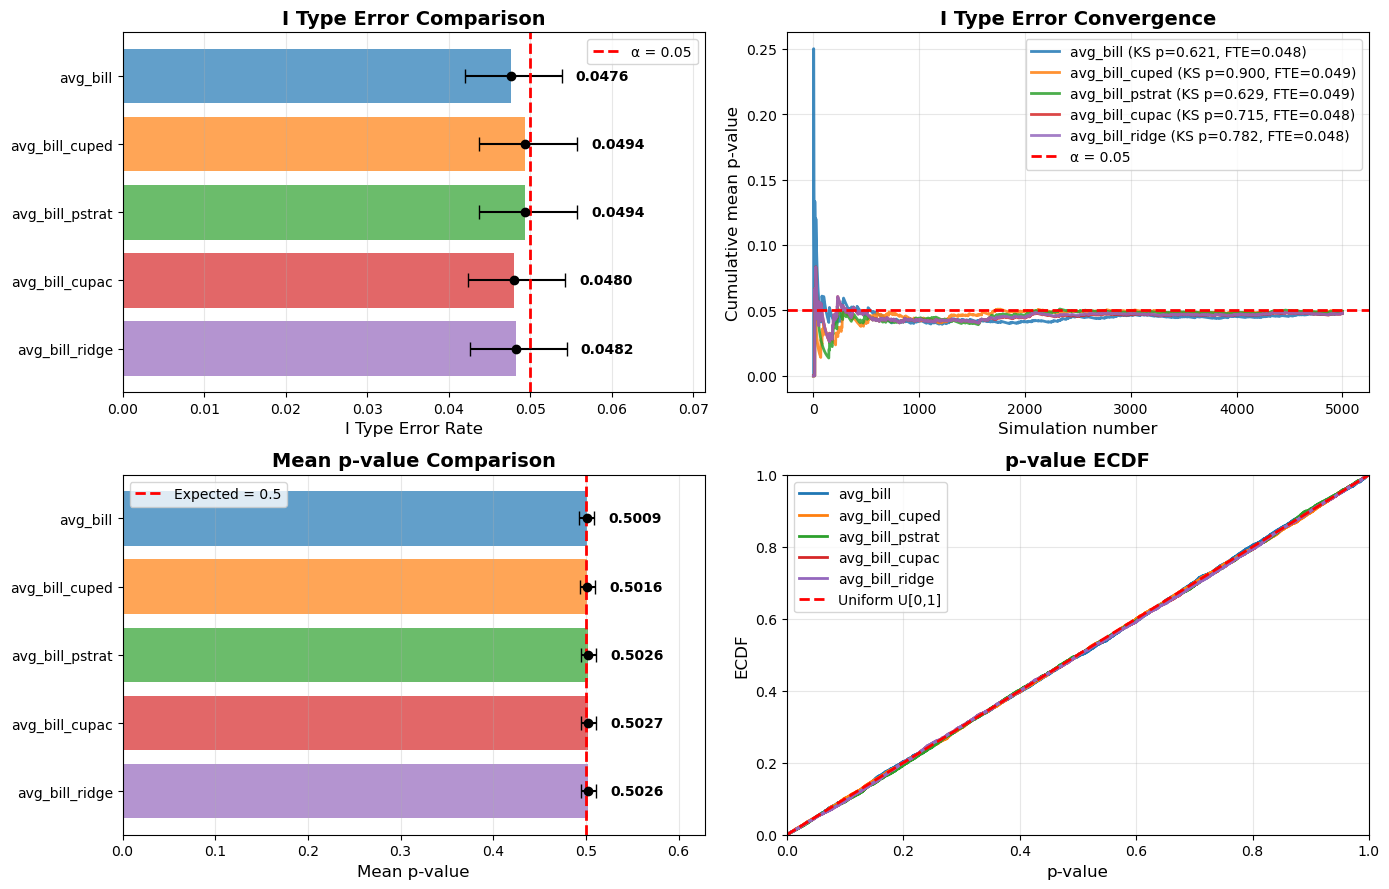


=== Power comparison (AB benchmark) ===


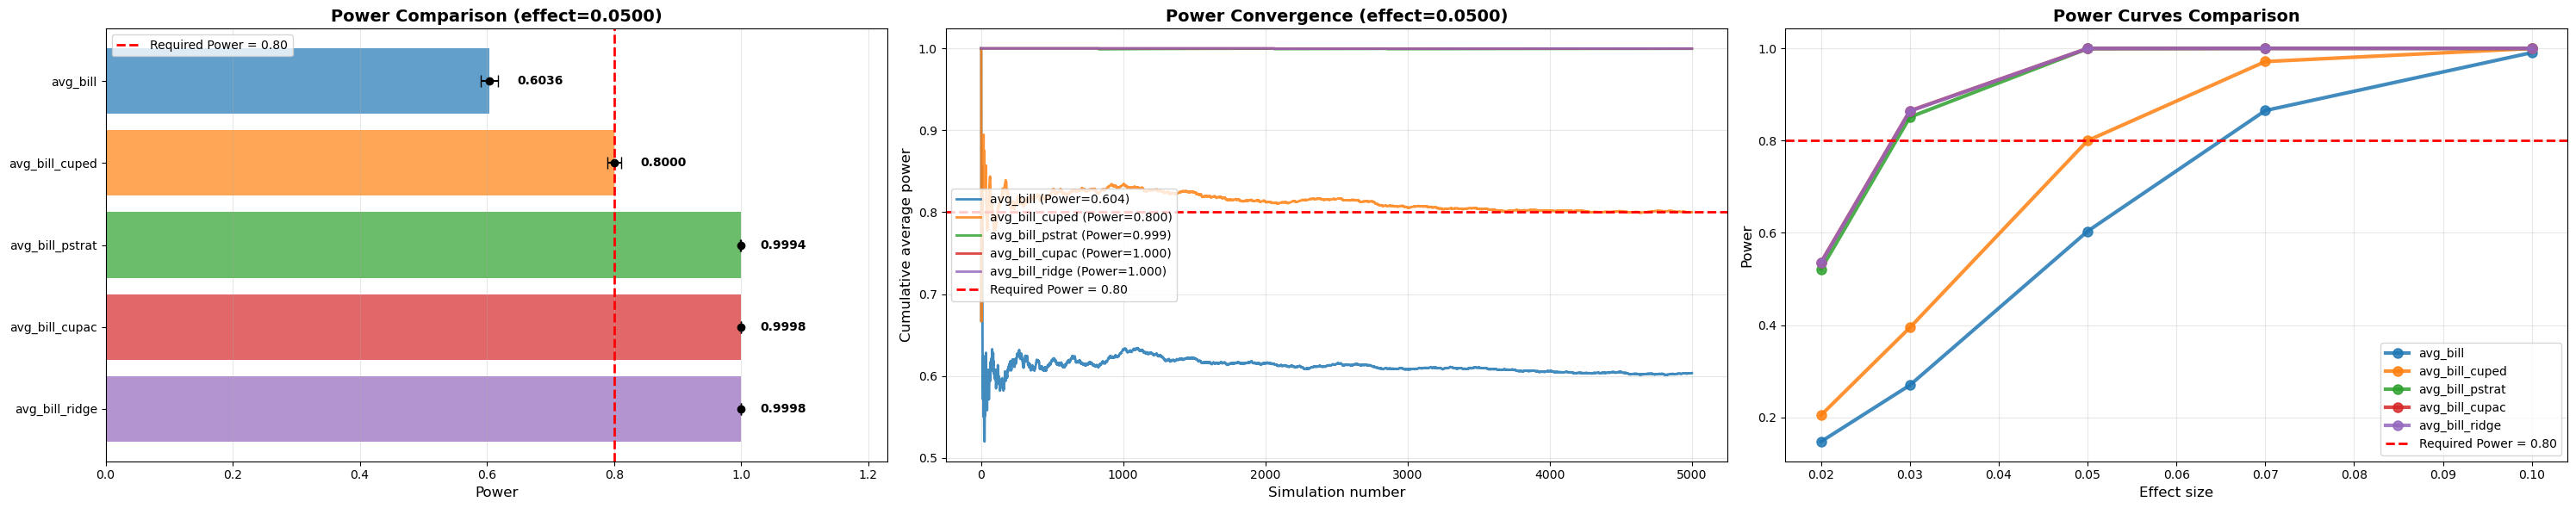


Power at 5% relative effect (avg_bill, linearized):
[0.6036, 0.8, 0.9994, 0.9998, 0.9998]


In [18]:
print("=== Type I error check (AA benchmark) ===")
aa_pv_ab, aa_st_ab = bm_ab.aa_benchmark(n_sims=N_SIMS, n_jobs=-1, verbose=False)

print("\n=== Power comparison (AB benchmark) ===")
ab_stats_ab, pc_ab = bm_ab.ab_benchmark(
    bar_effect=0.05,
    power_curve_effects=[0.02, 0.03, 0.05, 0.07, 0.10],
    n_sims=N_SIMS,
    n_jobs=-1,
    verbose=False,
)
print("\nPower at 5% relative effect (avg_bill, linearized):")
print([x['mean_p'] for x in ab_stats_ab])


## 9. Summary

### What we covered

| Method | Variance reduction | Type I error | Key requirement |
|---|---|---|---|
| **CUPED** | ✅ Good (~50% for ρ≈0.7) | ✅ Safe | Single numeric pre-experiment covariate |
| **Post-Stratification** | ✅ Good | ✅ Safe | Categorical strata with meaningful structure |
| **CUPAC (OLS)** | ✅ Best of the two | ✅ Safe | Both covariate types available |
| **CUPAC (Ridge)** | ✅ ≈ OLS at low dim | ✅ Safe | High-dim or correlated feature sets |
| **Custom transformer** | Depends on model | ⚠️ Validate! | Any (X, y) → adjusted_y function |

### Choosing a method

1. **Start with CUPED** if you have a strong pre-experiment metric (ρ > 0.5). Simple, interpretable, always safe.
2. **Add Post-Stratification** if good categorical segments exist (device type, region, user tier).
3. **Use CUPAC** when both are available — it subsumes both and is provably at least as good as either.
4. **Custom transformer (Ridge, GBM)** only when standard linear adjustment clearly underperforms; always validate Type I error via AA simulations.
5. **For ratio metrics** — linearize first, then apply any of the above via `AaDataRatio` + `DesignerRatioLin`.

### The plug-in pattern

```python
# The universal mcab integration pattern for any variance reduction method:
my_transformer = lambda X, y: <adjusted_y>           # your function here

data    = AaDataIid(raw_data, transformer=my_transformer, covariates=X)
# or for ratio metrics:
data    = AaDataRatio(ratio_data, transformer=my_transformer, covariates=X)

designer = DesignerIid(data, pval_func=pval_func)     # or DesignerRatioLin
aa_pvals = designer.aa_sims(n_sims=5_000)             # always validate Type I error first
```